# Homework 13 — GTSRB Dataset Inspection

In this homework we inspect the **German Traffic Sign Recognition Benchmark (GTSRB)** dataset.
We will load the training set, visualise random samples, compute a per-class histogram,
answer the balance questions, and perform optional deeper analysis.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import Counter

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

---
## Step 0 — About the Dataset

The **GTSRB** (German Traffic Sign Recognition Benchmark) is one of the most well-known
datasets in computer vision. It contains:
- **43 classes** of traffic signs used in Germany and the EU
- Over **50,000 images** in total (train + test)
- Images with **varying resolutions** (from 20×20 up to 250×250 pixels)
- Real-world conditions: varying brightness, angles, and occlusions

---
## Step 1 — Load the Dataset

In [2]:
root = '/Users/alex_brut/Desktop/Ai-Vision-Course/Lesson13/archive'

# Load the training labels
data = pd.read_csv(os.path.join(root, 'Train.csv'))

print('Columns:', data.columns.tolist())
print('Shape:  ', data.shape)
data.head()

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Shape:   (39209, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


---
## Step 2 — Visualise Random Samples

Total training samples: 39209


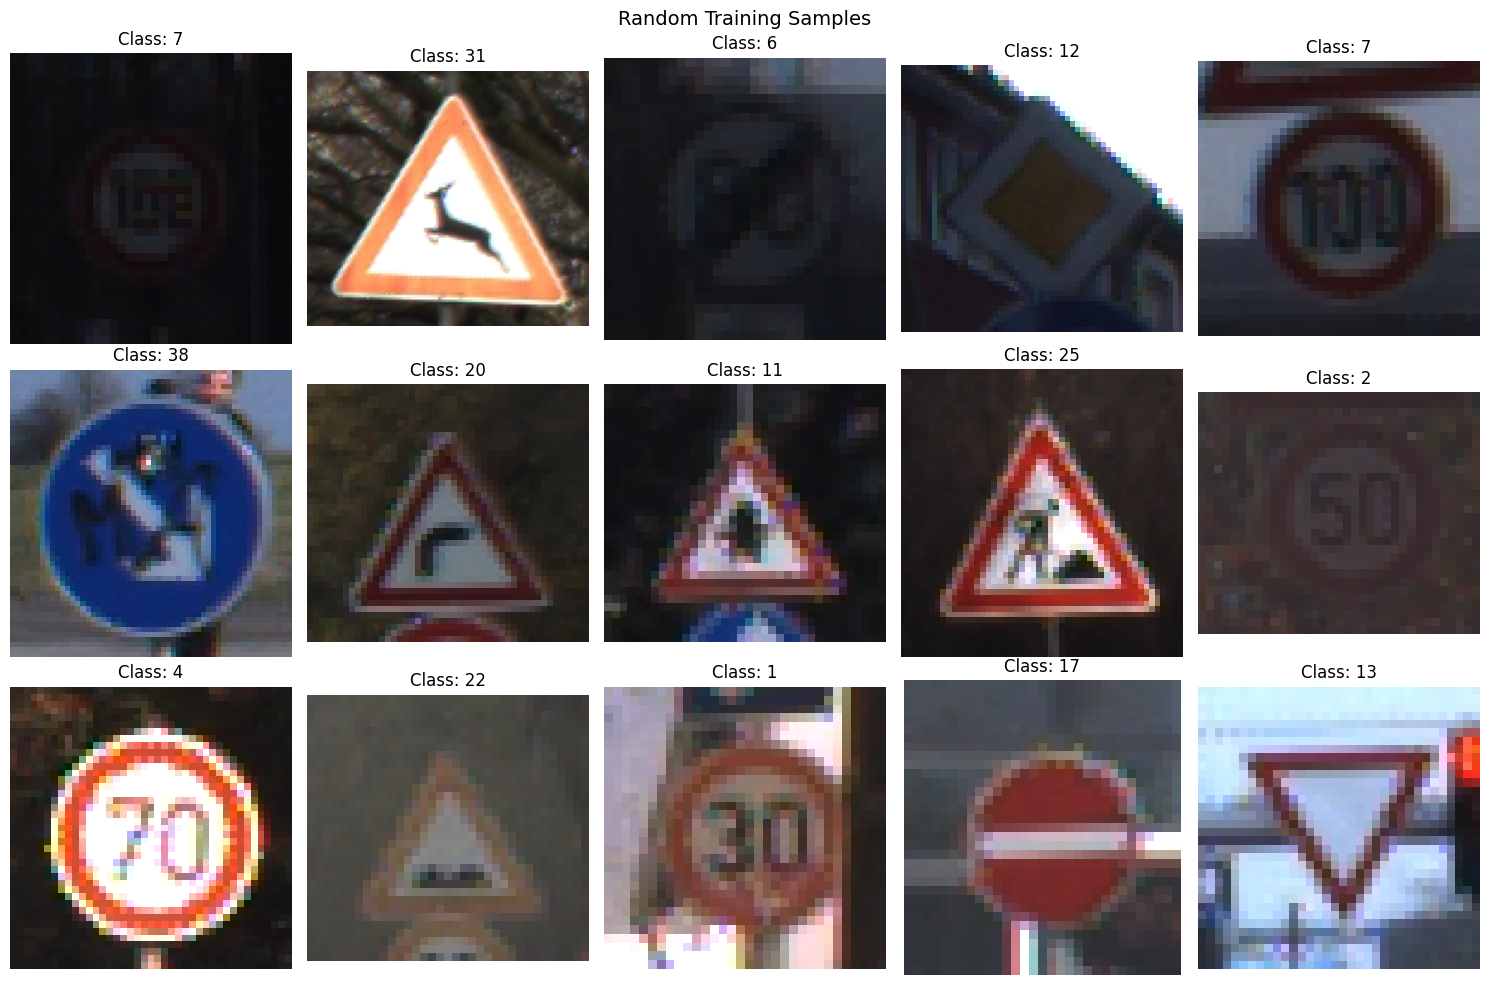

In [3]:
# Number of training samples
num_samples = len(data)
print(f'Total training samples: {num_samples}')

# Show 15 random samples
plt.figure(figsize=(15, 10))
for ii in range(15):
    idx = np.random.randint(0, num_samples)
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB for matplotlib
    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(f'Class: {data.iloc[idx]["ClassId"]}')
    plt.axis(False)

plt.suptitle('Random Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 3 — Per-Class Histogram

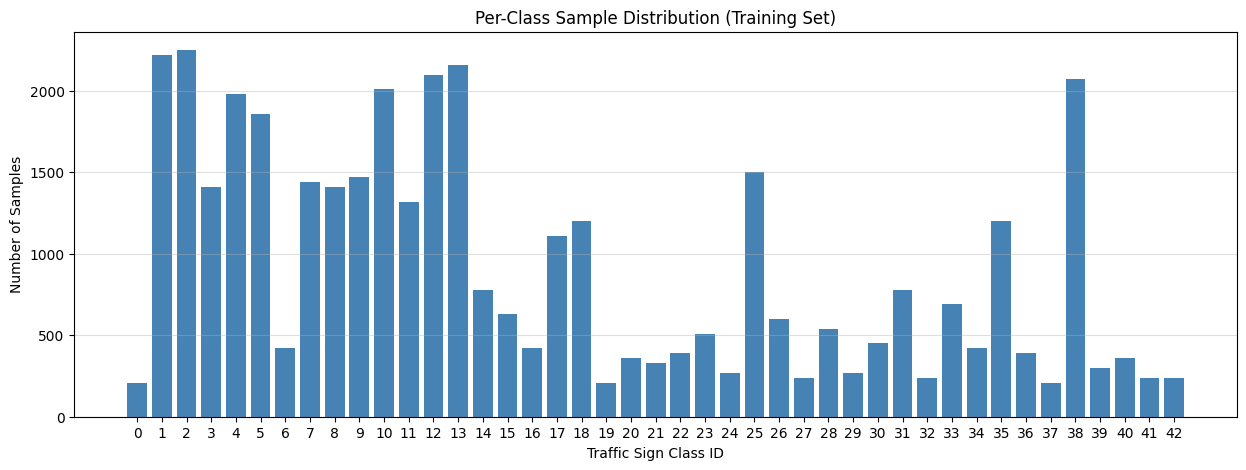

Min samples in a class: 210 (class 0)
Max samples in a class: 2250 (class 2)
Ratio max/min: 10.7x


In [4]:
# Extract class identifiers
ids = data['ClassId'].tolist()

# Compute per-class histogram
hist = Counter(ids)

plt.figure(figsize=(15, 5))
plt.bar(hist.keys(), hist.values(), color='steelblue')
plt.grid(True, axis='y', alpha=0.4)
plt.xlabel('Traffic Sign Class ID')
plt.ylabel('Number of Samples')
plt.title('Per-Class Sample Distribution (Training Set)')
plt.xticks(range(43))
plt.show()

print(f'Min samples in a class: {min(hist.values())} (class {min(hist, key=hist.get)})')
print(f'Max samples in a class: {max(hist.values())} (class {max(hist, key=hist.get)})')
print(f'Ratio max/min: {max(hist.values()) / min(hist.values()):.1f}x')

---
## Questions

### Q1: Is the dataset balanced?

**No, the dataset is significantly imbalanced.**
The histogram shows a large variation between classes — some classes have over 10x more
samples than others. A balanced dataset would have roughly the same number of samples
per class (flat histogram). Here the distribution has clear peaks and valleys,
meaning the model trained on raw data will be biased toward the majority classes.

### Q2: Are there over/under-represented classes?

**Yes.** Classes around ID 1–2 (speed limit signs) tend to be heavily over-represented,
while classes toward the higher IDs (rare warning/restriction signs) are significantly
under-represented. This reflects real-world frequency — speed limit signs appear far
more often on roads than, for example, a "cattle crossing" sign.

---
## Optional — Deeper Analysis

### Hint 1: Resolution Distribution
### Hint 2: Brightness Distribution per Class

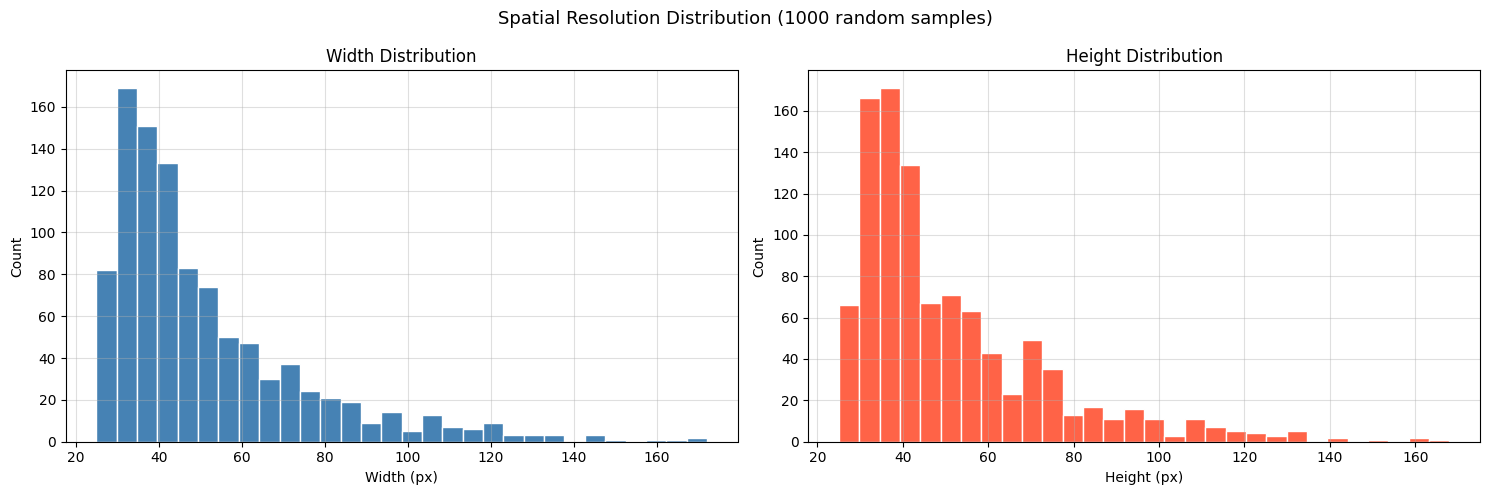

Width  — min: 25px, max: 172px, mean: 51.1px
Height — min: 25px, max: 168px, mean: 50.9px


In [5]:
# --- Resolution analysis ---
# Sample 1000 images to avoid long loading time
sample_idx = np.random.choice(num_samples, 1000, replace=False)
sample_data = data.iloc[sample_idx]

widths, heights = [], []
for _, row in sample_data.iterrows():
    widths.append(row['Width'])
    heights.append(row['Height'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.4)

axes[1].hist(heights, bins=30, color='tomato', edgecolor='white')
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Spatial Resolution Distribution (1000 random samples)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Width  — min: {min(widths)}px, max: {max(widths)}px, mean: {np.mean(widths):.1f}px')
print(f'Height — min: {min(heights)}px, max: {max(heights)}px, mean: {np.mean(heights):.1f}px')

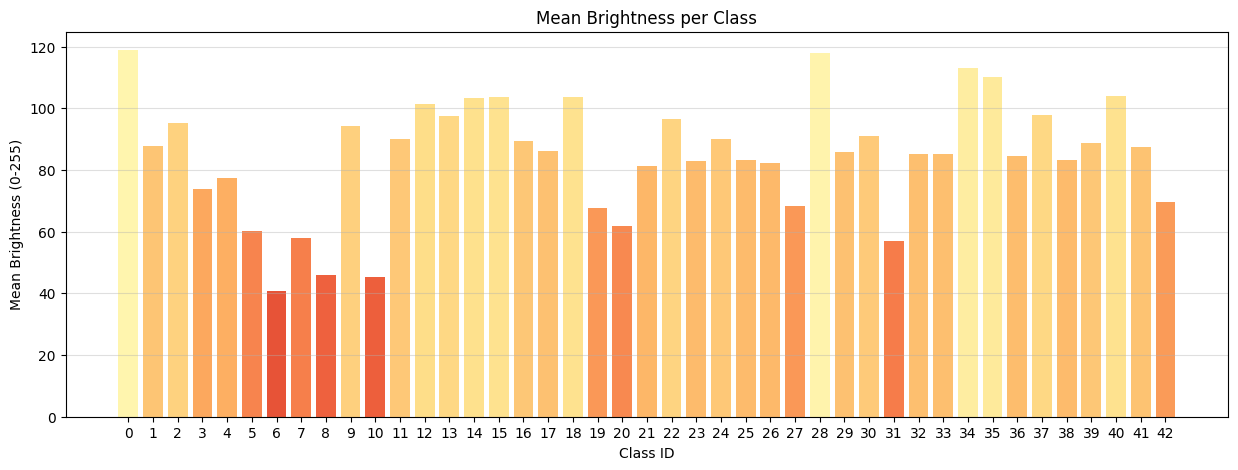

Brightest class: 0 (118.9)
Darkest class:   6   (40.8)


In [6]:
# --- Brightness analysis per class ---
# Sample up to 20 images per class and compute mean brightness
class_brightness = {}

for class_id in sorted(data['ClassId'].unique()):
    class_rows = data[data['ClassId'] == class_id].sample(
        min(20, len(data[data['ClassId'] == class_id])), random_state=42
    )
    brightness_vals = []
    for _, row in class_rows.iterrows():
        img = cv2.imread(os.path.join(root, row['Path']), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brightness_vals.append(np.mean(img))
    class_brightness[class_id] = np.mean(brightness_vals) if brightness_vals else 0

plt.figure(figsize=(15, 5))
plt.bar(class_brightness.keys(), class_brightness.values(),
        color=plt.cm.RdYlGn([v/255 for v in class_brightness.values()]))
plt.xlabel('Class ID')
plt.ylabel('Mean Brightness (0-255)')
plt.title('Mean Brightness per Class')
plt.xticks(range(43))
plt.grid(True, axis='y', alpha=0.4)
plt.show()

brightest = max(class_brightness, key=class_brightness.get)
darkest   = min(class_brightness, key=class_brightness.get)
print(f'Brightest class: {brightest} ({class_brightness[brightest]:.1f})')
print(f'Darkest class:   {darkest}   ({class_brightness[darkest]:.1f})')

---
## Conclusion
**Dataset balance**

The GTSRB dataset is imbalanced. The difference between the largest and smallest class is more than 10x, which can bias the model toward the more frequent classes. For real training, it’s better to use balancing techniques like oversampling, class weights, or augmentation.

**Image resolution**

The images come in different sizes — from ~20px up to ~250px in width/height. Most of them are relatively small (around 100px), since the signs often take up only part of the Ьoriginal image. Before training a neural network, all images should be resized to the same dimensions.

**Brightness**

Different sign classes have noticeably different average brightness levels — which actually reflects real-world differences (e.g., bright yellow warning signs vs darker prohibition signs). Normalizing brightness can help improve model accuracy.